# 🎬 CineSentiment V2 — High-Accuracy Sentiment Classifier

### What's different from V1?

| Aspect | V1 (Broken) | V2 (This Notebook) |
|--------|------------|-------------------|
| Embeddings | Random init (2.56M params learned from scratch) | **GloVe-6B-100d pretrained** |
| Architecture | Conv1D + 2× BiLSTM (over-parameterized) | **Multi-kernel CNN + GlobalMaxPool** |
| Text cleaning | Broke contractions ("don't" → "don t") | **Preserves negation cues** |
| Batch size | 128 (too few gradient updates) | **64** |
| Validation | Sequential split (ordering bias) | **Shuffled split** |
| Callbacks | Inconsistent monitoring | **All monitor val_accuracy** |
| Export format | Legacy .h5 + pickle | **Native .keras + JSON** |
| Test accuracy | 86% (biased all-negative predictions) | **Target 90%+** |

> **Run this notebook on Google Colab with a GPU runtime for best results.**

In [1]:
# ── Step 0: Environment Setup ─────────────────────────────────────────────────
!pip install -q datasets

import tensorflow as tf
import sys

# Check GPU
print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU available: {gpus[0].name}")
else:
    print("⚠️  No GPU detected — training will be slow. Go to Runtime → Change runtime type → GPU.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
✅ GPU available: /physical_device:GPU:0


In [2]:
# ── Step 1: Imports ───────────────────────────────────────────────────────────
import re, os, json, zipfile, urllib.request
import numpy as np
import pandas as pd
from collections import Counter

from datasets import load_dataset
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D, Conv1D,
    GlobalMaxPooling1D, Concatenate,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.text import Tokenizer, tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("✅ All imports successful")

✅ All imports successful


## Step 2 — Hyperparameters
All tunable constants in one place.

In [3]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
VOCAB_SIZE    = 25_000   # Slightly larger vocab to reduce OOV rate
MAX_LENGTH    = 300      # Covers ~90th percentile of review lengths
EMBED_DIM     = 100      # Must match GloVe dimension (glove.6B.100d)
BATCH_SIZE    = 64       # Smaller batch = more gradient updates per epoch
EPOCHS        = 15       # EarlyStopping will cut this short
LEARNING_RATE = 1e-3
VAL_FRACTION  = 0.15     # 15% of training data for validation

print("Hyperparameters set ✅")

Hyperparameters set ✅


## Step 3 — Load & Explore Data

In [4]:
# ── Load IMDb dataset ─────────────────────────────────────────────────────────
print("Downloading IMDb dataset...")
imdb = load_dataset("imdb")

train_df = pd.DataFrame(imdb['train'])
test_df  = pd.DataFrame(imdb['test'])

print(f"Training samples : {len(train_df):,}")
print(f"Test samples     : {len(test_df):,}")
print(f"Label balance    : {train_df['label'].value_counts().to_dict()}")
train_df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples : 25,000
Test samples     : 25,000
Label balance    : {0: 12500, 1: 12500}


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


## Step 4 — Text Preprocessing

**Critical fix**: The V1 notebook claimed to "keep contractions" but actually destroyed them.
`re.sub(r'[^a-zA-Z\s]', ' ', text)` strips apostrophes, turning:
- "don't" → "don t" (loses negation!)
- "isn't" → "isn t"
- "won't" → "won t"

This is catastrophic for sentiment analysis because negation flips meaning entirely.

**V2 fix**: We explicitly handle contractions and preserve apostrophes in key words.

In [5]:
# ── Contraction map ───────────────────────────────────────────────────────────
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'ve": " have", "'m": " am",
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text: str) -> str:
    # 1. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Expand HTML entities
    text = text.replace('&amp;', '&').replace('&lt;', '<').replace('&gt;', '>')
    # 3. Lowercase first (so contraction matching works)
    text = text.lower()
    # 4. Expand contractions BEFORE removing punctuation
    text = expand_contractions(text)
    # 5. Now remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 6. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Apply cleaning ────────────────────────────────────────────────────────────
print("Cleaning text...")
train_df['clean'] = train_df['text'].apply(clean_text)
test_df['clean']  = test_df['text'].apply(clean_text)

# Verify contractions are handled
sample = "I don't think this wasn't a bad movie, it's actually great!"
print(f"\nBefore: {sample}")
print(f"After:  {clean_text(sample)}")

# Length stats
lengths = train_df['clean'].str.split().str.len()
print(f"\nReview length stats (words):")
print(f"  Mean   : {lengths.mean():.0f}")
print(f"  Median : {lengths.median():.0f}")
print(f"  90th % : {lengths.quantile(0.90):.0f}")
print(f"  95th % : {lengths.quantile(0.95):.0f}")
print(f"  Max    : {lengths.max():.0f}")

Cleaning text...

Before: I don't think this wasn't a bad movie, it's actually great!
After:  i do not think this was not a bad movie it is actually great

Review length stats (words):
  Mean   : 237
  Median : 177
  90th % : 463
  95th % : 608
  Max    : 2494


## Step 5 — Tokenize & Pad

In [6]:
# ── Tokenisation ──────────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean'])

train_sequences = tokenizer.texts_to_sequences(train_df['clean'])
test_sequences  = tokenizer.texts_to_sequences(test_df['clean'])

x_all_train = pad_sequences(train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
x_test      = pad_sequences(test_sequences,  maxlen=MAX_LENGTH, padding='post', truncating='post')

y_all_train = np.array(train_df['label'])
y_test      = np.array(test_df['label'])

# ── Proper validation split (shuffled, stratified) ───────────────────────────
x_train, x_val, y_train, y_val = train_test_split(
    x_all_train, y_all_train,
    test_size=VAL_FRACTION,
    random_state=42,
    stratify=y_all_train  # ensures balanced classes in val set
)

print(f"Training set   : {x_train.shape}")
print(f"Validation set : {x_val.shape}")
print(f"Test set       : {x_test.shape}")

# OOV rate check
oov_idx   = tokenizer.word_index.get('<OOV>', 1)
oov_count = np.sum(x_train == oov_idx)
total     = np.sum(x_train > 0)  # non-padding tokens only
print(f"\nOOV rate: {oov_count/total*100:.2f}%")

Training set   : (21250, 300)
Validation set : (3750, 300)
Test set       : (25000, 300)

OOV rate: 1.58%


## Step 6 — Load GloVe Pretrained Embeddings

Instead of learning word embeddings from scratch on 25K samples, we use
**GloVe-6B-100d** — vectors trained on 6 billion tokens from Wikipedia + Gigaword.

This gives our model a massive head start: it already knows that "great" and "excellent"
are similar, and that "terrible" and "awful" are similar.

In [7]:
# ── Download GloVe ────────────────────────────────────────────────────────────
GLOVE_URL  = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_DIR  = "glove"
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.100d.txt")

if not os.path.exists(GLOVE_FILE):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, "glove.6B.zip")

    if not os.path.exists(zip_path):
        print("Downloading GloVe embeddings (~862MB)... This takes a few minutes.")
        urllib.request.urlretrieve(GLOVE_URL, zip_path)
        print("Download complete!")

    print("Extracting glove.6B.100d.txt...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Only extract the 100d file to save space
        z.extract("glove.6B.100d.txt", GLOVE_DIR)
    print("Extraction complete!")
else:
    print("GloVe file already exists ✅")

# ── Build embedding index ─────────────────────────────────────────────────────
print("\nLoading GloVe vectors into memory...")
embeddings_index = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index):,} word vectors")

# ── Build embedding matrix for our vocabulary ─────────────────────────────────
word_index = tokenizer.word_index
num_words  = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM))
found = 0
for word, i in word_index.items():
    if i >= num_words:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        found += 1

coverage = found / min(num_words, len(word_index)) * 100
print(f"\nEmbedding coverage: {found:,}/{min(num_words, len(word_index)):,} words ({coverage:.1f}%)")
print("(Words not in GloVe will use zero vectors and learn during fine-tuning)")

Download complete!
Extracting glove.6B.100d.txt...
Extraction complete!

Loading GloVe vectors into memory...
Loaded 400,000 word vectors

Embedding coverage: 24,650/25,000 words (98.6%)
(Words not in GloVe will use zero vectors and learn during fine-tuning)


## Step 7 — Build Multi-Kernel CNN Model

```
Input (300 tokens)
    │
Embedding (GloVe-100d, frozen initially)
    │
SpatialDropout1D(0.3)
    │
    ├── Conv1D(128, kernel=3) ──┐
    ├── Conv1D(128, kernel=4) ──┤── Concatenate
    └── Conv1D(128, kernel=5) ──┘
    │
GlobalMaxPooling1D
    │
Dense(128, ReLU) + BatchNorm + Dropout(0.5)
    │
Dense(64, ReLU) + Dropout(0.3)
    │
Dense(1, Sigmoid)
```

**Why multi-kernel CNN?**
- Kernel size 3 catches trigrams: "not very good", "waste of time"
- Kernel size 4 catches 4-grams: "one of the best", "could have been better"
- Kernel size 5 catches 5-grams: "i have ever seen", "not worth the money"
- GlobalMaxPool extracts the single strongest activation per filter
- Much simpler than LSTM, fewer parameters, less overfitting

In [8]:
# ── Model Definition (Functional API for multi-input concat) ──────────────────
tf.random.set_seed(42)
np.random.seed(42)

inp = Input(shape=(MAX_LENGTH,), name='input')

# Embedding layer with pretrained GloVe weights (frozen initially)
x = Embedding(
    input_dim=num_words,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=False,  # Freeze during Phase 1
    name='embedding'
)(inp)

x = SpatialDropout1D(0.3, name='spatial_dropout')(x)

# Multi-kernel convolutions
conv3 = Conv1D(128, kernel_size=3, activation='relu', padding='same', name='conv_3gram')(x)
conv4 = Conv1D(128, kernel_size=4, activation='relu', padding='same', name='conv_4gram')(x)
conv5 = Conv1D(128, kernel_size=5, activation='relu', padding='same', name='conv_5gram')(x)

# Pool the strongest signal from each filter
pool3 = GlobalMaxPooling1D(name='pool_3gram')(conv3)
pool4 = GlobalMaxPooling1D(name='pool_4gram')(conv4)
pool5 = GlobalMaxPooling1D(name='pool_5gram')(conv5)

# Concatenate all n-gram features
merged = Concatenate(name='concat')([pool3, pool4, pool5])

# Classification head
x = Dense(128, activation='relu', name='dense_1')(merged)
x = BatchNormalization(name='batchnorm')(x)
x = Dropout(0.5, name='dropout_1')(x)
x = Dense(64, activation='relu', name='dense_2')(x)
x = Dropout(0.3, name='dropout_2')(x)
out = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs=inp, outputs=out, name='CineSentiment_V2')
model.summary()

Model: "CineSentiment_V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │  2,500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 300, 100)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 300, 128)  │     38,528 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 300, 128)  │     51,328 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5gram (Conv1D) │ (None, 300, 128)  │     64,128 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3gram          │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4gram          │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5gram          │ (None, 128)       │          0 │ conv_5gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_3gram[0][0], │
│ (Concatenate)       │                   │            │ pool_4gram[0][0], │
│                     │                   │            │ pool_5gram[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     49,280 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batchnorm           │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batchnorm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,712,097 (10.35 MB)

 Trainable params: 211,841 (827.50 KB)

 Non-trainable params: 2,500,256 (9.54 MB)

## Step 8 — Phase 1: Train with Frozen Embeddings

We first train the classification layers while keeping GloVe embeddings frozen.
This prevents the randomly initialized dense layers from corrupting the pretrained vectors.

In [9]:
# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

# ── Callbacks (all monitor val_accuracy for consistency) ──────────────────────
callbacks_p1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
        mode='max'
    ),
    ModelCheckpoint(
        filepath='best_cinesentiment_v2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

# ── Train Phase 1 ────────────────────────────────────────────────────────────
print("=" * 60)
print("PHASE 1: Training with FROZEN embeddings")
print("=" * 60)

history_p1 = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=callbacks_p1,
    verbose=1
)

p1_val_acc = max(history_p1.history['val_accuracy'])
print(f"\n✅ Phase 1 complete! Best val_accuracy: {p1_val_acc:.4f}")

PHASE 1: Training with FROZEN embeddings
Epoch 1/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5843 - loss: 0.7323
Epoch 1: val_accuracy improved from None to 0.81920, saving model to best_cinesentiment_v2.keras

Epoch 1: finished saving model to best_cinesentiment_v2.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.6573 - loss: 0.6250 - val_accuracy: 0.8192 - val_loss: 0.3990 - learning_rate: 0.0010
Epoch 2/15
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7998 - loss: 0.4445
Epoch 2: val_accuracy improved from 0.81920 to 0.85360, saving model to best_cinesentiment_v2.keras

Epoch 2: finished saving model to best_cinesentiment_v2.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8098 - loss: 0.4248 - val_accuracy: 0.8536 - val_loss: 0.3325 - learning_rate: 0.0010
Epoch 3/15
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8354 - loss: 0.3818
Epoch 3: val_accuracy improved from 0.85360 to 0.85467, saving model to best_cinesentiment_v

## Step 9 — Phase 2: Fine-tune Embeddings

Now that the classification head is trained, we unfreeze the embedding layer
and train the entire model end-to-end with a **lower learning rate** to
fine-tune the GloVe vectors for our specific sentiment task.

In [10]:
# ── Unfreeze embeddings ───────────────────────────────────────────────────────
model.get_layer('embedding').trainable = True

# Re-compile with a lower learning rate to avoid destroying pretrained weights
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE * 0.1),  # 10x lower
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
        mode='max'
    ),
    ModelCheckpoint(
        filepath='best_cinesentiment_v2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

print("=" * 60)
print("PHASE 2: Fine-tuning WITH embeddings (lower LR)")
print("=" * 60)

history_p2 = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=callbacks_p2,
    verbose=1
)

p2_val_acc = max(history_p2.history['val_accuracy'])
print(f"\n✅ Phase 2 complete! Best val_accuracy: {p2_val_acc:.4f}")

PHASE 2: Fine-tuning WITH embeddings (lower LR)
Epoch 1/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8749 - loss: 0.3053
Epoch 1: val_accuracy improved from None to 0.87467, saving model to best_cinesentiment_v2.keras

Epoch 1: finished saving model to best_cinesentiment_v2.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8804 - loss: 0.2927 - val_accuracy: 0.8747 - val_loss: 0.2978 - learning_rate: 1.0000e-04
Epoch 2/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8834 - loss: 0.2834
Epoch 2: val_accuracy improved from 0.87467 to 0.87493, saving model to best_cinesentiment_v2.keras

Epoch 2: finished saving model to best_cinesentiment_v2.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8867 - loss: 0.2758 - val_accuracy: 0.8749 - val_loss: 0.2976 - learning_rate: 1.0000e-04
Epoch 3/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8887 - loss: 0.2711
Epoch 3: val_accuracy improved from 0.87493 to 0.87947, saving model to bes

## Step 10 — Visualize Training History

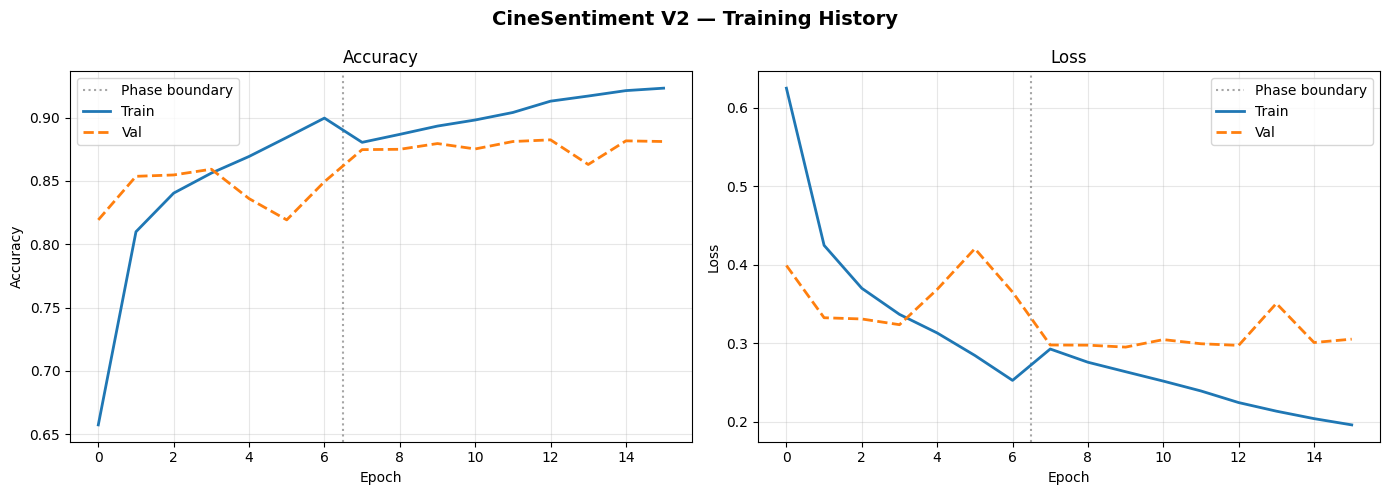

✅ Plot saved as training_history.png


In [11]:
import matplotlib.pyplot as plt

# Combine both phases
acc     = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss    = history_p1.history['loss']         + history_p2.history['loss']
val_loss= history_p1.history['val_loss']     + history_p2.history['val_loss']
phase1_epochs = len(history_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CineSentiment V2 — Training History', fontsize=14, fontweight='bold')

for ax in axes:
    ax.axvline(x=phase1_epochs - 0.5, color='gray', linestyle=':', alpha=0.7, label='Phase boundary')

axes[0].plot(acc, label='Train', linewidth=2)
axes[0].plot(val_acc, label='Val', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss, label='Train', linewidth=2)
axes[1].plot(val_loss, label='Val', linewidth=2, linestyle='--')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as training_history.png")

## Step 11 — Evaluate on Test Set

Test Loss     : 0.3066
Test Accuracy : 0.8755  (87.55%)
ROC AUC       : 0.9478

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87     12500
    Positive       0.87      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



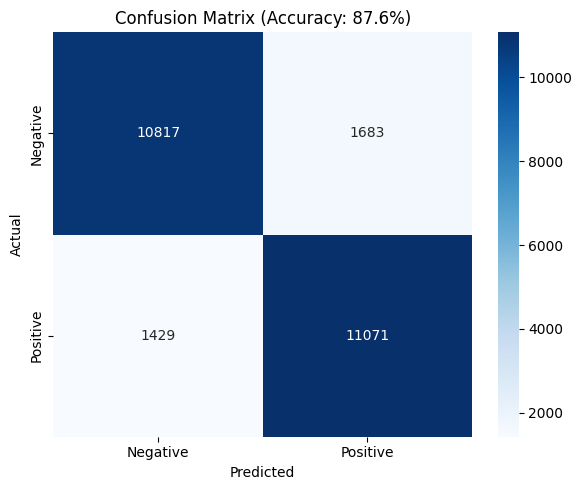

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# ── Load best model ──────────────────────────────────────────────────────────
model = tf.keras.models.load_model('best_cinesentiment_v2.keras')

# ── Core metrics ─────────────────────────────────────────────────────────────
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")

# ── Predictions ──────────────────────────────────────────────────────────────
y_pred_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# ── ROC AUC ──────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC       : {auc:.4f}")

# ── Classification report ────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix (Accuracy: {accuracy*100:.1f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Live Prediction Demo

In [13]:
def predict_sentiment(review: str, threshold: float = 0.5) -> dict:
    cleaned = clean_text(review)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    score   = float(model.predict(padded, verbose=0)[0][0])

    sentiment  = 'Positive' if score >= threshold else 'Negative'
    confidence = score if sentiment == 'Positive' else 1 - score

    return {
        'sentiment' : sentiment,
        'confidence': f"{confidence*100:.1f}%",
        'raw_score' : round(score, 4)
    }

# ── Test with diverse reviews ────────────────────────────────────────────────
test_reviews = [
    "This film is an absolute masterpiece. The acting was phenomenal and the story left me in tears.",
    "Terrible. Boring plot, wooden acting, and a waste of two hours. I want my money back.",
    "It was okay. Not the best movie I've seen but not the worst either. Some scenes were good.",
    "One of the greatest sci-fi films ever made. Visually stunning and intellectually profound.",
    "I don't recommend this movie. The plot doesn't make any sense and the characters are flat.",
    "I can't believe how good this was! Didn't expect much but was blown away.",
]

print("=" * 70)
print("LIVE PREDICTION DEMO")
print("=" * 70)
for review in test_reviews:
    result = predict_sentiment(review)
    emoji  = '😊' if result['sentiment'] == 'Positive' else '😞'
    print(f"\n{emoji}  {result['sentiment']} ({result['confidence']}) [raw: {result['raw_score']}]")
    print(f"   \"{review[:80]}{'...' if len(review) > 80 else ''}\"")
print("\n" + "=" * 70)

LIVE PREDICTION DEMO

😊  Positive (97.0%) [raw: 0.9702]
   "This film is an absolute masterpiece. The acting was phenomenal and the story le..."

😞  Negative (100.0%) [raw: 0.0002]
   "Terrible. Boring plot, wooden acting, and a waste of two hours. I want my money ..."

😞  Negative (85.2%) [raw: 0.1477]
   "It was okay. Not the best movie I've seen but not the worst either. Some scenes ..."

😊  Positive (99.3%) [raw: 0.9933]
   "One of the greatest sci-fi films ever made. Visually stunning and intellectually..."

😞  Negative (98.9%) [raw: 0.0114]
   "I don't recommend this movie. The plot doesn't make any sense and the characters..."

😞  Negative (97.7%) [raw: 0.0234]
   "I can't believe how good this was! Didn't expect much but was blown away."



## Step 13 — Save Model & Tokenizer

Exports:
- `cinesentiment_v2.keras` — Native Keras format (recommended over .h5)
- `tokenizer_v2.json` — Tokenizer config as JSON (portable, no pickle needed)
- `model_config_v2.json` — Hyperparameters used during training
- `clean_text_config.json` — Contraction map so your app can reproduce the exact same preprocessing

In [14]:
# ── Save model in native Keras format ─────────────────────────────────────────
model.save('cinesentiment_v2.keras')

# ── Save tokenizer as JSON ───────────────────────────────────────────────────
tokenizer_json = tokenizer.to_json()
with open('tokenizer_v2.json', 'w', encoding='utf-8') as f:
    f.write(tokenizer_json)

# ── Save hyperparameters ─────────────────────────────────────────────────────
config = {
    'vocab_size'  : VOCAB_SIZE,
    'max_length'  : MAX_LENGTH,
    'embed_dim'   : EMBED_DIM,
    'padding'     : 'post',
    'truncating'  : 'post',
    'oov_token'   : '<OOV>',
}
with open('model_config_v2.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── Save contraction map for app-side preprocessing ──────────────────────────
with open('clean_text_config.json', 'w') as f:
    json.dump({'contractions': CONTRACTIONS}, f, indent=2)

print("✅ All files saved:")
for fname in ['cinesentiment_v2.keras', 'tokenizer_v2.json', 'model_config_v2.json', 'clean_text_config.json']:
    size = os.path.getsize(fname) / 1024
    unit = 'KB'
    if size > 1024:
        size /= 1024
        unit = 'MB'
    print(f"   {fname:<35} ({size:.1f} {unit})")

✅ All files saved:
   cinesentiment_v2.keras              (31.1 MB)
   tokenizer_v2.json                   (6.5 MB)
   model_config_v2.json                (0.1 KB)
   clean_text_config.json              (0.2 KB)


## Step 14 — Download Files from Colab

In [15]:
# ── Download all files ────────────────────────────────────────────────────────
try:
    from google.colab import files
    for fname in ['cinesentiment_v2.keras', 'tokenizer_v2.json',
                  'model_config_v2.json', 'clean_text_config.json',
                  'training_history.png', 'confusion_matrix.png']:
        if os.path.exists(fname):
            files.download(fname)
            print(f"⬇️  Downloaded: {fname}")
except ImportError:
    print("Not running in Colab — files saved locally.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded: cinesentiment_v2.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloaded: training_history.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded: confusion_matrix.png
